In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [46]:
dataset_path = "./data/food-101/images"

print(os.listdir(dataset_path)[:20])

['.DS_Store', 'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry']


In [56]:
food_names = {
    0: "apple_pie",
    1: "baklava",
    2: "beet_salad",
    3: "cheesecake",
    4: "cheese_plate"
}

In [57]:
calorie_map = {
    "apple_pie": 296,
    "baklava": 334,
    "beet_salad": 123,
    "cheesecake": 321,
    "cheese_plate": 350
}

In [58]:
data = []
labels = []

image_size = 128

for idx, food in enumerate(food_classes):

    food_path = os.path.join(dataset_path, food)

    images = os.listdir(food_path)[:40]

    for image_name in images:

        img_path = os.path.join(food_path, image_name)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (image_size, image_size))

        img = img / 255.0

        data.append(img.flatten())

        labels.append(idx)

print("Images loaded successfully!")

Images loaded successfully!


In [59]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (200, 49152)
Labels shape: (200,)


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 49152)
Testing data: (40, 49152)


In [61]:
from sklearn.svm import SVC

model = SVC(kernel="rbf")

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [62]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 0 0 0 0 2 2 0 2 0]


In [63]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.225


In [ ]:
# Note:
# Food image classification is a complex multi-class problem.
# Classical machine learning models like SVM may achieve limited accuracy on highly varied food datasets.
# Accuracy can be significantly improved using deep learning models such as Convolutional Neural Networks (CNNs).

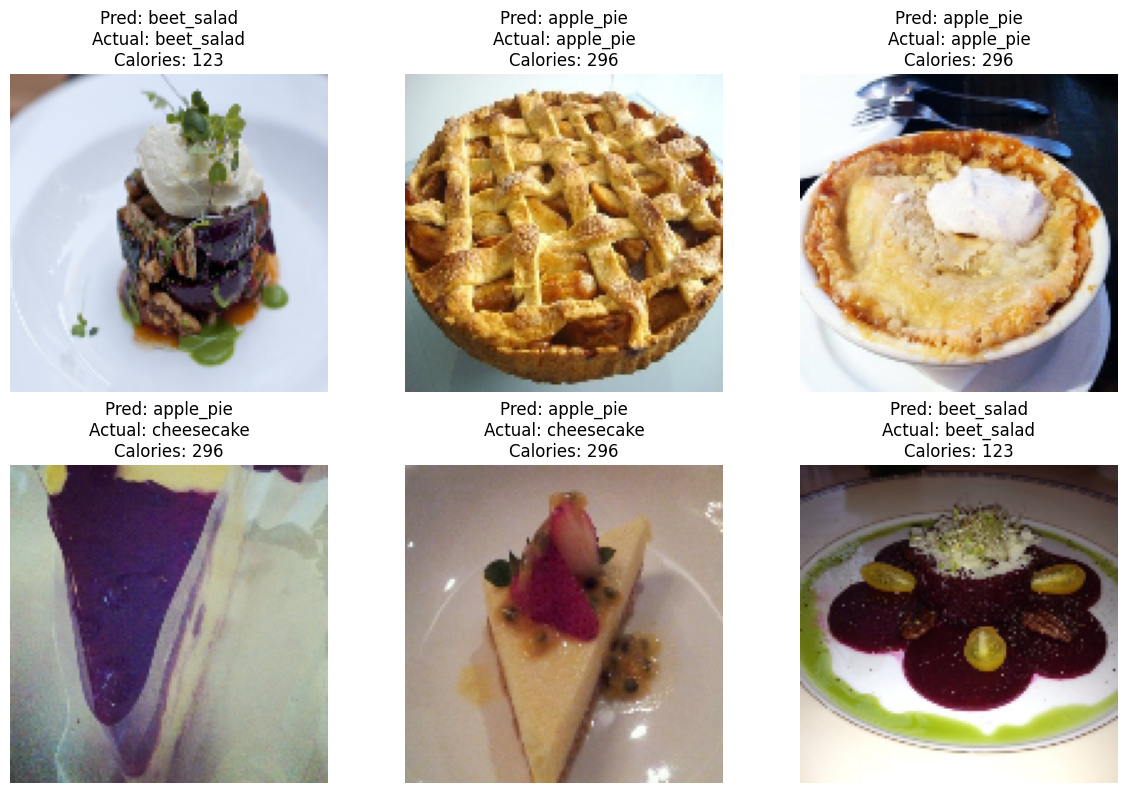

In [66]:
food_names = {
    0: "apple_pie",
    1: "baklava",
    2: "beet_salad",
    3: "cheesecake",
    4: "cheese_plate"
}

calorie_map = {
    "apple_pie": 296,
    "baklava": 334,
    "beet_salad": 123,
    "cheesecake": 321,
    "cheese_plate": 350
}

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_test[i].reshape(128,128,3)

    plt.imshow(cv2.cvtColor((img*255).astype("uint8"), cv2.COLOR_BGR2RGB))

    pred_food = food_names[y_pred[i]]

    actual_food = food_names[y_test[i]]

    calories = calorie_map[pred_food]

    plt.title(
        f"Pred: {pred_food}\n"
        f"Actual: {actual_food}\n"
        f"Calories: {calories}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
import pickle

with open("models/food_calorie_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
